In [1]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [ ]:
DATA_DIR = "preprocessed_data/Cross"
BATCH_SIZE = 8
EPOCHS = 30
LEARNING_RATE = 1e-3
NUM_CLASSES = 4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

Using device: cuda


In [ ]:
# Class name to index mapping
CLASS_NAMES = ["rest", "task_motor", "task_story_math", "task_working_memory"]
CLASS_TO_IDX = {name: idx for idx, name in enumerate(CLASS_NAMES)}


class MEGDataset(Dataset):
    def __init__(self, file_paths, labels):
        self.file_paths = file_paths
        self.labels = labels

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        x = pd.read_csv(self.file_paths[idx], index_col=0).values.astype(np.float32)
        # Keep the input in the read shape: (3564, 249)
        # Conv1d expects (batch, channels, length), so the model will use 3564 channels.

        # Per-sensor normalization across the time axis
        mean = x.mean(axis=1, keepdims=True)
        std = x.std(axis=1, keepdims=True) + 1e-6
        x = (x - mean) / std

        x = torch.tensor(x)
        y = torch.tensor(self.labels[idx]).long()

        return x, y


# ============================================================
# LOAD FILES
# ============================================================

train_files = []
# test_files = []
train_labels = []
# test_labels = []

# Load data from preprocessed_data directory
for split_type in os.listdir(DATA_DIR):
    split_path = os.path.join(DATA_DIR, split_type)
    if not os.path.isdir(split_path):
        continue
    
    print(f"Loading {split_type} data...")
    
    for file_name in sorted(os.listdir(split_path)):
        if not file_name.endswith(".csv"):
            continue
        
        file_path = os.path.join(split_path, file_name)
        
        # Extract class name from filename
        # Format: class_name_..._subject_id.csv
        parts = file_name.split("_")
        # Remove the last part (subject_id) and extension
        class_name = "_".join(parts[:-2]).replace(".csv", "")
        
        if class_name not in CLASS_TO_IDX:
            print(f"Warning: Unknown class '{class_name}' in {file_name}")
            continue
        
        class_idx = CLASS_TO_IDX[class_name]
        
        if split_type == "train":
            train_files.append(file_path)
            train_labels.append(class_idx)
        # else:
        #     test_files.append(file_path)
        #     test_labels.append(class_idx)

print(f"Loaded {len(train_files)} training samples")
# print(f"Loaded {len(test_files)} test samples")
print(f"Class distribution in training: {np.bincount(train_labels)}")
# print(f"Class distribution in test: {np.bincount(test_labels)}")

Loading test1 data...
Loading test2 data...
Loading test3 data...
Loading train data...
Loaded 64 training samples
Loaded 48 test samples
Class distribution in training: [16 16 16 16]
Class distribution in test: [12 12 12 12]


In [ ]:
# TODO: cross validation per file

train_dataset = MEGDataset(train_files, train_labels)


# test_dataset = MEGDataset(test_files, test_labels)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_loader = DataLoader(
    # test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

print(f"Train batches: {len(train_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 8
Test batches: 6


In [5]:
class TCNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super().__init__()

        padding = (kernel_size - 1) * dilation // 2

        self.conv1 = nn.Conv1d(
            in_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation,
        )

        self.bn1 = nn.BatchNorm1d(out_channels)

        self.conv2 = nn.Conv1d(
            out_channels,
            out_channels,
            kernel_size,
            padding=padding,
            dilation=dilation,
        )

        self.bn2 = nn.BatchNorm1d(out_channels)

        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)

        self.residual = nn.Conv1d(in_channels, out_channels, 1)

    def forward(self, x):
        residual = self.residual(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.dropout(out)

        out = self.conv2(out)
        out = self.bn2(out)

        out = out + residual
        out = self.relu(out)

        return out


class MEGTCN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.block1 = TCNBlock(3563, 64, kernel_size=7, dilation=1)
        self.pool1 = nn.MaxPool1d(2)

        self.block2 = TCNBlock(64, 128, kernel_size=5, dilation=2)
        self.pool2 = nn.MaxPool1d(2)

        self.block3 = TCNBlock(128, 128, kernel_size=3, dilation=4)
        self.pool3 = nn.MaxPool1d(2)

        self.global_pool = nn.AdaptiveAvgPool1d(1)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        # x shape:
        # (batch, 3564, 249)

        x = self.block1(x)
        x = self.pool1(x)

        x = self.block2(x)
        x = self.pool2(x)

        x = self.block3(x)
        x = self.pool3(x)

        x = self.global_pool(x)

        x = self.classifier(x)

        return x


In [6]:
model = MEGTCN(num_classes=NUM_CLASSES).to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

for epoch in range(EPOCHS):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for batch_idx, (x, y) in enumerate(train_loader):
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        optimizer.zero_grad()

        outputs = model(x)
        loss = criterion(outputs, y)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = outputs.max(1)
        total += y.size(0)
        correct += predicted.eq(y).sum().item()

    train_acc = 100.0 * correct / total
    avg_loss = running_loss / len(train_loader)

    print(
        f"Epoch {epoch+1}/{EPOCHS} | "
        f"Loss: {avg_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}%"
    )

Epoch 1/30 | Loss: 1.4054 | Train Acc: 32.81%
Epoch 2/30 | Loss: 1.3953 | Train Acc: 29.69%
Epoch 3/30 | Loss: 1.2848 | Train Acc: 45.31%
Epoch 4/30 | Loss: 1.2960 | Train Acc: 37.50%
Epoch 5/30 | Loss: 1.1354 | Train Acc: 56.25%
Epoch 6/30 | Loss: 0.9453 | Train Acc: 68.75%
Epoch 7/30 | Loss: 0.9849 | Train Acc: 59.38%
Epoch 8/30 | Loss: 0.8363 | Train Acc: 68.75%
Epoch 9/30 | Loss: 0.7903 | Train Acc: 65.62%
Epoch 10/30 | Loss: 0.6476 | Train Acc: 75.00%
Epoch 11/30 | Loss: 0.7374 | Train Acc: 68.75%
Epoch 12/30 | Loss: 0.6910 | Train Acc: 75.00%
Epoch 13/30 | Loss: 0.4584 | Train Acc: 87.50%
Epoch 14/30 | Loss: 0.4805 | Train Acc: 84.38%
Epoch 15/30 | Loss: 0.3383 | Train Acc: 93.75%
Epoch 16/30 | Loss: 0.4282 | Train Acc: 87.50%
Epoch 17/30 | Loss: 0.2509 | Train Acc: 96.88%
Epoch 18/30 | Loss: 0.1294 | Train Acc: 100.00%
Epoch 19/30 | Loss: 0.2208 | Train Acc: 96.88%
Epoch 20/30 | Loss: 0.1828 | Train Acc: 96.88%
Epoch 21/30 | Loss: 0.2450 | Train Acc: 93.75%
Epoch 22/30 | Loss: 0

In [7]:
model.eval()

correct = 0
total = 0

with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        y = y.to(DEVICE)

        outputs = model(x)

        _, predicted = outputs.max(1)

        total += y.size(0)
        correct += predicted.eq(y).sum().item()


test_acc = 100.0 * correct / total

print(f"\nTest Accuracy: {test_acc:.2f}%")


Test Accuracy: 35.42%


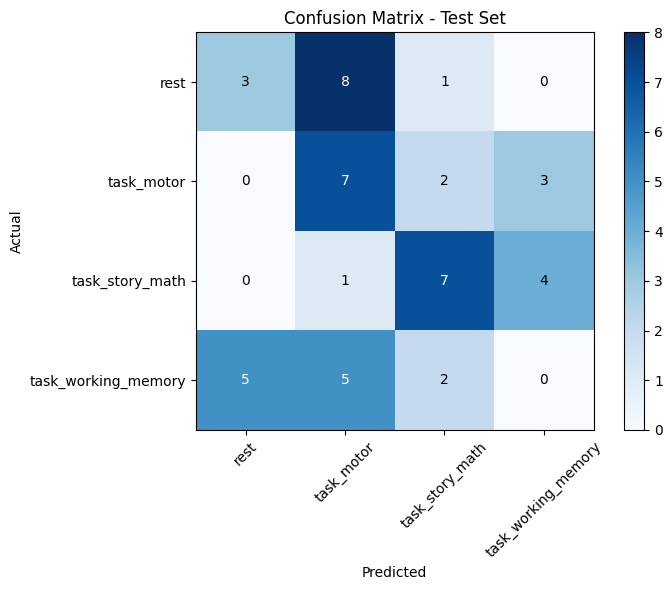

   Actual  Predicted     Actual_Class  Predicted_Class
0       0          1             rest       task_motor
1       0          1             rest       task_motor
2       0          2             rest  task_story_math
3       0          1             rest       task_motor
4       1          1       task_motor       task_motor
5       1          1       task_motor       task_motor
6       1          1       task_motor       task_motor
7       1          1       task_motor       task_motor
8       2          1  task_story_math       task_motor
9       2          2  task_story_math  task_story_math


In [8]:
from sklearn.metrics import confusion_matrix

# Get predictions and actual labels for all test samples
all_predictions = []
all_actuals = []

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(DEVICE)
        outputs = model(x)
        _, predicted = outputs.max(1)
        all_predictions.extend(predicted.cpu().numpy())
        all_actuals.extend(y.numpy())

# Create a comparison dataframe
results_df = pd.DataFrame({
    'Actual': all_actuals,
    'Predicted': all_predictions
})

# Map indices back to class names
results_df['Actual_Class'] = results_df['Actual'].map({idx: name for name, idx in CLASS_TO_IDX.items()})
results_df['Predicted_Class'] = results_df['Predicted'].map({idx: name for name, idx in CLASS_TO_IDX.items()})

# Create a confusion matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(all_actuals, all_predictions)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar()
plt.xticks(range(NUM_CLASSES), CLASS_NAMES, rotation=45)
plt.yticks(range(NUM_CLASSES), CLASS_NAMES)
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(j, i, str(cm[i, j]), ha='center', va='center', color='white' if cm[i, j] > cm.max() / 2 else 'black')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

print(results_df.head(10))